<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/rna-seq/12_uctan_uca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uçtan uca: serinin tamamı tek defterde

On bir rehberin çekirdek hattı, tek akışta: tablo → filtre → cetvel → model → volkan → zenginleştirme → harita → kimlik paneli. Her hücre, ait olduğu rehberde tek tek kurulmuş kodun kendisidir; açıklamaları orada, koşusu burada. Kurulum ve model uydurma dahil iki-üç dakika sürer.

In [1]:
%pip install -q pydeseq2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==

## Tablo, filtre, cetvel (Rehber 6-7)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t = pd.read_csv('https://raw.githubusercontent.com/melissa-04/melisayla-biyoinformatik/main/data/rna-seq/sayim_tablosu.csv')
ornekler = ['WT_1', 'WT_2', 'WT_3', 'KO_1', 'KO_2', 'KO_3']
g = t.set_index('gen_id')[ornekler]

def gen(ad, tablo):
    return tablo.loc[t.loc[t.gen_adi == ad, 'gen_id'].iloc[0]]

poz = g[(g > 0).all(axis=1)]
logg = np.log(poz)
sf = np.exp(logg.sub(logg.mean(axis=1), axis=0).median(axis=0))
norm = g.div(sf, axis=1)

sayim = g.T
sayim = sayim[sayim.columns[sayim.sum(axis=0) >= 10]]
meta = pd.DataFrame({'genotip': ['WT'] * 3 + ['KO'] * 3}, index=sayim.index)
print(sayim.shape[1], 'gen kaldı | cetvel:', sf.round(2).to_dict())

21994 gen kaldı | cetvel: {'WT_1': 0.76, 'WT_2': 0.63, 'WT_3': 1.98, 'KO_1': 0.88, 'KO_2': 1.28, 'KO_3': 0.96}


## Model ve sonuç tablosu (Rehber 8)

In [3]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

dds = DeseqDataSet(counts=sayim, metadata=meta,
                   design="~genotip", ref_level=["genotip", "WT"], quiet=True)
dds.deseq2()
st = DeseqStats(dds, contrast=["genotip", "KO", "WT"], quiet=True)
st.summary()

sonuc = st.results_df
sonuc['gen_adi'] = t.set_index('gen_id')['gen_adi'].reindex(sonuc.index)
anlamli = sonuc[(sonuc.padj < 0.05) & (sonuc.log2FoldChange.abs() > 1)]
print('Anlamlı:', len(anlamli),
      '| yükselen:', int((anlamli.log2FoldChange > 0).sum()),
      '| düşen:', int((anlamli.log2FoldChange < 0).sum()))

/tmp/ipykernel_2652/1939198194.py:4: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(counts=sayim, metadata=meta,


Anlamlı: 1388 | yükselen: 632 | düşen: 756


## Volkan (Rehber 8)

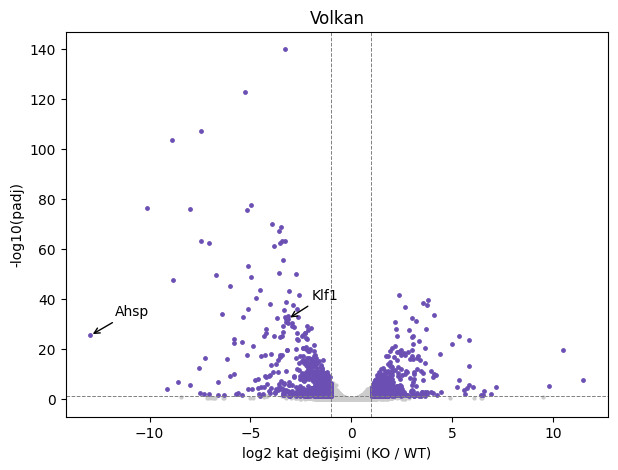

In [4]:
ciz = sonuc.dropna(subset=['padj']).copy()
ciz['y'] = -np.log10(ciz.padj)
onem = (ciz.padj < 0.05) & (ciz.log2FoldChange.abs() > 1)

plt.figure(figsize=(7, 5))
plt.scatter(ciz.log2FoldChange[~onem], ciz.y[~onem], s=4, c='#CCCCCC')
plt.scatter(ciz.log2FoldChange[onem], ciz.y[onem], s=6, c='#6B4FB3')
for ad in ['Klf1', 'Ahsp']:
    n = ciz[ciz.gen_adi == ad].iloc[0]
    plt.annotate(ad, (n.log2FoldChange, n.y),
                 xytext=(n.log2FoldChange + 1.2, n.y + 8),
                 arrowprops=dict(arrowstyle='->'))
plt.axhline(-np.log10(0.05), ls='--', lw=0.7, c='gray')
plt.axvline(-1, ls='--', lw=0.7, c='gray'); plt.axvline(1, ls='--', lw=0.7, c='gray')
plt.xlabel('log2 kat değişimi (KO / WT)'); plt.ylabel('-log10(padj)')
plt.title('Volkan');

## Zenginleştirme (Rehber 9)

In [5]:
setler = {
 'hem_biyosentezi': ['Alas2','Alad','Hmbs','Uros','Urod','Cpox','Ppox','Fech','Slc25a38'],
 'demir_metabolizmasi': ['Slc25a37','Tfrc','Slc11a2','Steap3','Fth1','Ftl1','Ireb2','Aco1','Slc40a1','Tfr2'],
 'eritrosit_zar_iskeleti': ['Slc4a1','Spta1','Sptb','Ank1','Epb41','Epb42','Dmtn','Add2','Gypa','Gypc','Rhag'],
 'globinler_yetiskin': ['Hba-a1','Hba-a2','Hbb-bs','Hbb-bt'],
 'globinler_embriyonik': ['Hbb-y','Hbb-bh1','Hba-x'],
 'eritroid_tf': ['Gata1','Klf1','Tal1','Nfe2','Zfpm1','Lmo2','Gfi1b','Epor'],
 'mitokondriyal_solunum': ['mt-Co1','mt-Co2','mt-Co3','mt-Nd1','mt-Nd2','mt-Nd4','mt-Cytb','mt-Atp6'],
 'translasyon': ['Eef1a1','Eef2','Eif4a1','Rpl4','Rpl6','Rps3','Rps6','Rpl13a','Rps19','Rpl11'],
 'hepatosit_programi': ['Alb','Afp','Apoa1','Apoa2','Apob','Ttr','Ahsg','Fga','Fgb','Fgg'],
 'hucre_dongusu': ['Mki67','Ccnb1','Ccna2','Cdk1','Top2a','Plk1','Bub1','Aurkb','Mcm2','Pcna'],
 'apoptoz': ['Bax','Bak1','Casp3','Casp9','Bcl2','Bcl2l1','Bid','Apaf1','Trp53','Bbc3'],
 'otofaji': ['Atg5','Atg7','Map1lc3b','Becn1','Sqstm1','Ulk1','Atg3','Atg12'],
}

In [6]:
from scipy.stats import hypergeom

evren = sonuc.dropna(subset=['padj'])
evren_adlar = set(evren.gen_adi)
dusen = set(anlamli[anlamli.log2FoldChange < 0].gen_adi)
yukselen = set(anlamli[anlamli.log2FoldChange > 0].gen_adi)

def ora(liste, N_adlar):
    N = len(N_adlar)
    n = len(liste & N_adlar)
    satirlar = []
    for ad, gl in setler.items():
        S = set(gl) & N_adlar
        K = len(S)
        k = len(S & liste)
        p = hypergeom.sf(k - 1, N, K, n) if k > 0 else 1.0
        satirlar.append((ad, k, K, p))
    df = pd.DataFrame(satirlar, columns=['set', 'örtüşme', 'set_boyu', 'p']).sort_values('p').reset_index(drop=True)
    m = len(df)
    df['padj'] = np.minimum.accumulate((df.p * m / (df.index + 1))[::-1])[::-1]
    return df

print(ora(dusen, evren_adlar).head(5).to_string(index=False, float_format=lambda x: f'{x:.2e}'))

                   set  örtüşme  set_boyu        p     padj
eritrosit_zar_iskeleti        6        11 2.63e-06 3.15e-05
       hem_biyosentezi        5         9 1.72e-05 1.03e-04
           eritroid_tf        3         8 3.96e-03 1.58e-02
   demir_metabolizmasi        3        10 7.94e-03 2.38e-02
    globinler_yetiskin        2         4 1.08e-02 2.59e-02


## Harita (Rehber 10)

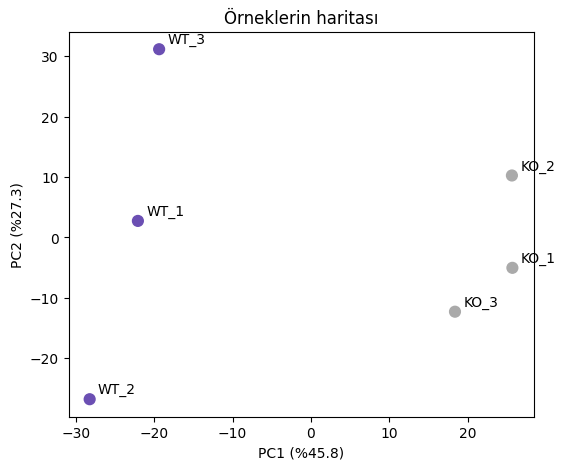

In [7]:
sesli = norm[norm.mean(axis=1) >= 20]
ln = np.log1p(sesli)
degisken = ln.var(axis=1).sort_values(ascending=False)
ust = ln.loc[degisken.head(500).index]

X = ust.T - ust.T.mean(axis=0)
U, S, Vt = np.linalg.svd(X, full_matrices=False)
pay = S**2 / (S**2).sum() * 100
PC = pd.DataFrame(U * S, index=ornekler, columns=[f'PC{i+1}' for i in range(len(S))])

plt.figure(figsize=(6, 5))
plt.scatter(PC['PC1'], PC['PC2'], s=60, c=['#6B4FB3'] * 3 + ['#AAAAAA'] * 3)
for s in ornekler:
    plt.annotate(s, (PC.loc[s, 'PC1'], PC.loc[s, 'PC2']),
                 textcoords='offset points', xytext=(6, 4))
plt.xlabel(f'PC1 (%{pay[0]:.1f})'); plt.ylabel(f'PC2 (%{pay[1]:.1f})')
plt.title('Örneklerin haritası');

## Kimlik paneli (Rehber 11)

In [8]:
panel = ['Klf1', 'Ahsp', 'Dmtn', 'Hbb-bs', 'E2f2', 'Slc4a1', 'Epb42', 'Hbb-y']
satirlar = []
for ad in panel:
    v = gen(ad, norm)
    wt, ko = v[:3].mean(), v[3:].mean()
    satirlar.append((ad, round(wt), round(ko), round(ko / wt, 4)))
print(pd.DataFrame(satirlar, columns=['gen', 'WT_ort', 'KO_ort', 'KO/WT']).to_string(index=False))

import pydeseq2, scipy
print('\npydeseq2', pydeseq2.__version__, '| pandas', pd.__version__, '| scipy', scipy.__version__)

   gen  WT_ort  KO_ort  KO/WT
  Klf1   11449    1296 0.1132
  Ahsp   99368      13 0.0001
  Dmtn   10546      61 0.0058
Hbb-bs   37039     570 0.0154
  E2f2    9443     990 0.1049
Slc4a1  107508   36082 0.3356
 Epb42    5552    1861 0.3352
 Hbb-y   13956  131603 9.4299

pydeseq2 0.5.4 | pandas 3.0.5 | scipy 1.16.3
